In [219]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [220]:
protein = "VCAM1"

In [266]:
vgat_geph_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGAT-GEPH_output_data/metric_results.csv"
vgat_geph_results = pd.read_csv(vgat_geph_results_file)
vgat_geph_results

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
0,0,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,48,10,0.155255,0.032665,6.883428,1.448246,0.255541,0.0,...,199.862944,16.532498,8.652007,61.032492,25.066581,0.203442,0.159660,LacZ-gRNA,CA3 SO,Brain-4-2
1,1,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,16,7,0.148589,0.043393,12.059629,3.521793,0.166916,0.0,...,256.204743,62.603057,24.357880,121.853710,48.500905,0.107266,0.109731,VCAM1-gRNA,CA1 SLM,Brain-4-2
2,2,CRISPR-Exp5_IHC-Exp7_Brain-7_section-1_LacZ-gR...,47,3,0.149219,0.034030,8.248187,1.881016,0.220473,0.0,...,161.937354,64.146090,11.572748,116.905820,22.674420,0.100435,0.107973,LacZ-gRNA,DG ML,Brain-7
3,3,CRISPR-Exp5_IHC-Exp7_Brain-7_section-2_LacZ-gR...,40,7,0.142098,0.017769,4.823511,0.603152,0.208208,0.0,...,181.818659,16.146739,5.235291,61.511265,14.741440,0.209936,0.155173,LacZ-gRNA,CA3 SO,Brain-7
4,4,CRISPR-Exp4_IHC-Exp7_Brain-4_section-3_LacZ-gR...,34,11,0.194297,0.043563,15.821661,3.547351,0.245212,0.0,...,278.558761,51.140526,27.058188,108.562219,54.356930,0.116985,0.110707,LacZ-gRNA,CA1 SLM,Brain-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,171,CRISPR-Exp4_IHC-Exp7_Brain-4_section-2_VCAM1-g...,59,14,0.229095,0.039123,14.806185,2.528467,0.248884,0.0,...,190.967989,13.777081,16.532498,50.959515,63.986913,0.203838,0.213290,VCAM1-gRNA,CA3 SR,Brain-4
172,172,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-3_LacZ-...,35,5,0.099158,0.029285,4.021012,1.187562,0.160338,0.0,...,142.060966,80.678588,5.180183,152.357177,9.415302,0.104069,0.100163,LacZ-gRNA,DG ML,Brain-4-2
173,173,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,5,0,0.198776,0.041028,8.890526,1.835013,0.306157,0.0,...,130.883171,8.266249,7.935599,44.946739,32.912667,0.299645,0.228560,VCAM1-gRNA,DG Hilus,Brain-4-2
174,174,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,75,11,0.234714,0.041852,19.387754,3.457048,0.281830,0.0,...,199.935429,23.090388,16.201848,84.265764,61.737873,0.201112,0.209993,LacZ-gRNA,CA3 SR,Brain-4-2


In [267]:
vgat_geph_results["target"] = vgat_geph_results["gRNA"].str.cat(vgat_geph_results[["Brain"]], sep = "_")

In [268]:
vgat_geph_results

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain,target
0,0,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,48,10,0.155255,0.032665,6.883428,1.448246,0.255541,0.0,...,16.532498,8.652007,61.032492,25.066581,0.203442,0.159660,LacZ-gRNA,CA3 SO,Brain-4-2,LacZ-gRNA_Brain-4-2
1,1,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,16,7,0.148589,0.043393,12.059629,3.521793,0.166916,0.0,...,62.603057,24.357880,121.853710,48.500905,0.107266,0.109731,VCAM1-gRNA,CA1 SLM,Brain-4-2,VCAM1-gRNA_Brain-4-2
2,2,CRISPR-Exp5_IHC-Exp7_Brain-7_section-1_LacZ-gR...,47,3,0.149219,0.034030,8.248187,1.881016,0.220473,0.0,...,64.146090,11.572748,116.905820,22.674420,0.100435,0.107973,LacZ-gRNA,DG ML,Brain-7,LacZ-gRNA_Brain-7
3,3,CRISPR-Exp5_IHC-Exp7_Brain-7_section-2_LacZ-gR...,40,7,0.142098,0.017769,4.823511,0.603152,0.208208,0.0,...,16.146739,5.235291,61.511265,14.741440,0.209936,0.155173,LacZ-gRNA,CA3 SO,Brain-7,LacZ-gRNA_Brain-7
4,4,CRISPR-Exp4_IHC-Exp7_Brain-4_section-3_LacZ-gR...,34,11,0.194297,0.043563,15.821661,3.547351,0.245212,0.0,...,51.140526,27.058188,108.562219,54.356930,0.116985,0.110707,LacZ-gRNA,CA1 SLM,Brain-4,LacZ-gRNA_Brain-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,171,CRISPR-Exp4_IHC-Exp7_Brain-4_section-2_VCAM1-g...,59,14,0.229095,0.039123,14.806185,2.528467,0.248884,0.0,...,13.777081,16.532498,50.959515,63.986913,0.203838,0.213290,VCAM1-gRNA,CA3 SR,Brain-4,VCAM1-gRNA_Brain-4
172,172,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-3_LacZ-...,35,5,0.099158,0.029285,4.021012,1.187562,0.160338,0.0,...,80.678588,5.180183,152.357177,9.415302,0.104069,0.100163,LacZ-gRNA,DG ML,Brain-4-2,LacZ-gRNA_Brain-4-2
173,173,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,5,0,0.198776,0.041028,8.890526,1.835013,0.306157,0.0,...,8.266249,7.935599,44.946739,32.912667,0.299645,0.228560,VCAM1-gRNA,DG Hilus,Brain-4-2,VCAM1-gRNA_Brain-4-2
174,174,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,75,11,0.234714,0.041852,19.387754,3.457048,0.281830,0.0,...,23.090388,16.201848,84.265764,61.737873,0.201112,0.209993,LacZ-gRNA,CA3 SR,Brain-4-2,LacZ-gRNA_Brain-4-2


In [271]:
df2_grouped_brain = vgat_geph_results.groupby(["target", "hippocampal_layer"], as_index=False)[["local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]].mean()

In [270]:
df_grouped_section = vgat_geph_results[["target",
                                        "hippocampal_layer",
                                        "img_filename",
                                        "local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]]
final_df = df_grouped_section.reset_index()

In [272]:
# to long format
df_melted = df2_grouped_brain.melt(id_vars=['target', 'hippocampal_layer'], var_name='metric', value_name='value')

# create new column based on hippocampal layer and metric
df_melted['hippocampal_layer_metric'] = df_melted['hippocampal_layer'] + '_' + df_melted['metric']

# pivot the dataframe back
df_pivot = df_melted.pivot(index='target', columns='hippocampal_layer_metric', values='value')

final_df = df_pivot.reset_index()

In [273]:
features = list(final_df.columns)
columns_to_remove = ["index", "target", "hippocampal_layer", "img_filename"]

for column in columns_to_remove:
    if column in features:  # Check if the column exists in the list
        features.remove(column)

print(features)

['CA1 SLM_local_peak_colocalized_spots', 'CA1 SLM_overlap_coeff', 'CA1 SLM_overlap_um2', 'CA1 SLM_pearson_cor', 'CA1 SLM_post_mean_puncta_size_um2', 'CA1 SLM_post_puncta_density_per_100_um2', 'CA1 SLM_post_staining_area_um2', 'CA1 SLM_postsynapse_image_mfi', 'CA1 SLM_pre_mean_puncta_size_um2', 'CA1 SLM_pre_puncta_density_per_100_um2', 'CA1 SLM_pre_staining_area_um2', 'CA1 SLM_presynapse_image_mfi', 'CA1 SO_local_peak_colocalized_spots', 'CA1 SO_overlap_coeff', 'CA1 SO_overlap_um2', 'CA1 SO_pearson_cor', 'CA1 SO_post_mean_puncta_size_um2', 'CA1 SO_post_puncta_density_per_100_um2', 'CA1 SO_post_staining_area_um2', 'CA1 SO_postsynapse_image_mfi', 'CA1 SO_pre_mean_puncta_size_um2', 'CA1 SO_pre_puncta_density_per_100_um2', 'CA1 SO_pre_staining_area_um2', 'CA1 SO_presynapse_image_mfi', 'CA1 SR_local_peak_colocalized_spots', 'CA1 SR_overlap_coeff', 'CA1 SR_overlap_um2', 'CA1 SR_pearson_cor', 'CA1 SR_post_mean_puncta_size_um2', 'CA1 SR_post_puncta_density_per_100_um2', 'CA1 SR_post_staining_ar

In [274]:
# separating out the features
X = final_df.loc[:,features].values
# separating out the target
Y = final_df.loc[:,["target"]].values

In [275]:
scaled_data = StandardScaler().fit_transform(X)

In [276]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

In [277]:
pc_df = pd.DataFrame(data = principal_components, columns = ['principal component 1', 'principal component 2'])
pc_df.head(5)

,principal component 1,principal component 2
0,-8.571401,2.272324
1,4.067269,-3.149051
2,0.574951,9.602311
3,5.517030,-0.016704
4,-9.593328,-4.679306


In [278]:
pca.explained_variance_ratio_

array([0.30927883, 0.21912562])

In [279]:
pca_df = pd.concat([pc_df, final_df[['target']]], axis = 1)
pca_df.head(10)

,principal component 1,principal component 2,target
0,-8.571401,2.272324,LacZ-gRNA_Brain-4
1,4.067269,-3.149051,LacZ-gRNA_Brain-4-2
2,0.574951,9.602311,LacZ-gRNA_Brain-5
3,5.517030,-0.016704,LacZ-gRNA_Brain-7
4,-9.593328,-4.679306,VCAM1-gRNA_Brain-4
5,2.156690,-3.475310,VCAM1-gRNA_Brain-4-2
6,1.708061,3.388694,VCAM1-gRNA_Brain-5
7,4.140727,-3.942958,VCAM1-gRNA_Brain-7


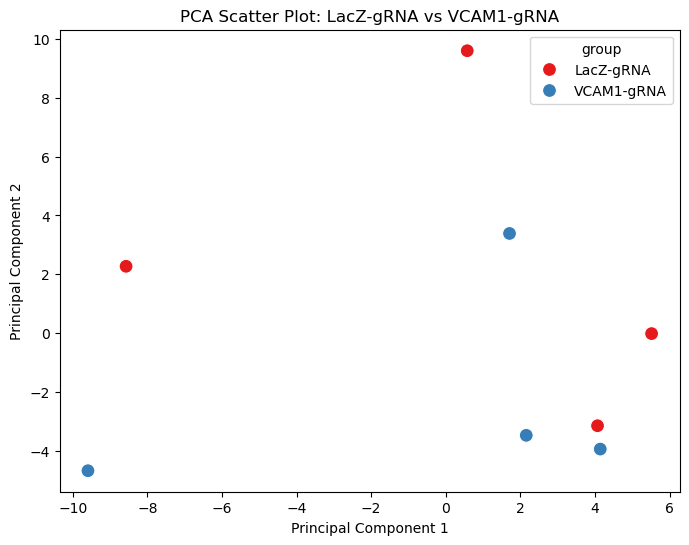

In [280]:
# Step 1: Create a new column to group targets into "LacZ-gRNA" and "VCAM1-gRNA"
pca_df['group'] = pca_df['target'].apply(lambda x: 'LacZ-gRNA' if 'LacZ' in x else 'VCAM1-gRNA')

# Step 2: Create a scatter plot using Seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='principal component 1', 
    y='principal component 2', 
    hue='group',  # Use the new 'group' column for coloring
    palette='Set1',  # Set1 is a good palette for distinct colors
    s=100  # Marker size
)

# Add title and labels
plt.title('PCA Scatter Plot: LacZ-gRNA vs VCAM1-gRNA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Show the plot
plt.show()

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

iris.frame

In [262]:
import umap

In [263]:
reducer = umap.UMAP()

In [264]:
embedding = reducer.fit_transform(scaled_data)
embedding.shape

/Users/cgeyskens/miniconda3/envs/synapse-counting-2/lib/python3.11/site-packages/umap/umap_.py:2437: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


(8, 2)

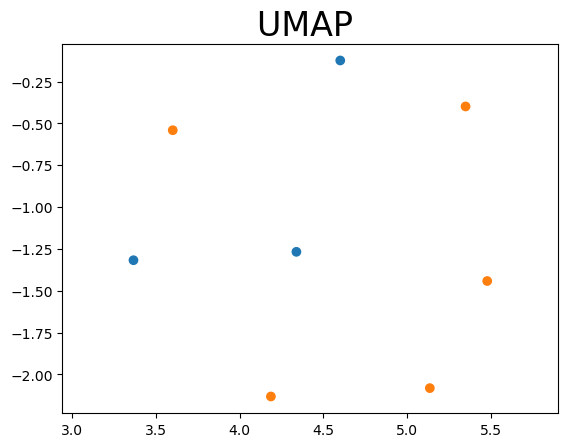

In [265]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in final_df.target.map({"LacZ-gRNA_Brain-4":0, 
                                                            "LacZ-gRNA_Brain-4-2":1, 
                                                            "LacZ-gRNA_Brain-5":0,
                                                            "LacZ-gRNA_Brain-7":0,
                                                            "VCAM1-gRNA_Brain-4":1,
                                                            "VCAM1-gRNA_Brain-4-2":1,
                                                            "VCAM1-gRNA_Brain-5":1,
                                                            "VCAM1-gRNA_Brain-7":1})])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP ', fontsize=24);

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Corrected label mapping
label_map = {
    "CA1 SLM_VCAM1-gRNA": 0, 
    "CA1 SLM_LacZ-gRNA": 1, 
    "CA1 SR_VCAM1-gRNA": 2, 
    "CA1 SR_LacZ-gRNA": 3,
    "CA1 SO_VCAM1-gRNA": 4, 
    "CA1 SO_LacZ-gRNA": 5, 
    "CA3 SO_VCAM1-gRNA": 6, 
    "CA3 SO_LacZ-gRNA": 7,
    "CA3 SL_VCAM1-gRNA": 8, 
    "CA3 SL_LacZ-gRNA": 9, 
    "CA3 SR_VCAM1-gRNA": 10, 
    "CA3 SR_LacZ-gRNA": 11,
    "DG Hilus_VCAM1-gRNA": 12, 
    "DG Hilus_LacZ-gRNA": 13,
    "DG ML_VCAM1-gRNA": 14, 
    "DG ML_LacZ-gRNA": 15
}

label_map_gRNA = {
    "VCAM1-gRNA": 0, 
    "LacZ-gRNA": 1
}

# Generate base colors for each layer
base_colors = sns.color_palette("husl", n_colors=2)

# Create color palette with slight variations for VCAM1 and LacZ
colors = []
for base_color in base_colors:
    # Slightly darker color for VCAM1-gRNA
    colors.append(tuple(max(0, c - 0.1) for c in base_color))
    # Slightly lighter color for LacZ-gRNA
    colors.append(tuple(min(1, c + 0.1) for c in base_color))

# Map the labels to colors
color_values = [colors[x] for x in vglut1_psd95_results.gRNA.map(label_map_gRNA)]

# Create a larger plot with smaller dots
plt.figure(figsize=(8, 8))  # Increase the plot size

# Plot the scatter points
scatter = plt.scatter(
    embedding[:, 0],  # X-axis values
    embedding[:, 1],  # Y-axis values
    c=color_values,   # Colors based on mapped labels
    s=15             # Dot size, reduced for smaller dots
)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP Visualization', fontsize=24)

# Create a legend manually
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, 
                      markerfacecolor=colors[i], markersize=10) 
           for label, i in label_map_gRNA.items()]
plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

